# Word Cloud in Natural Language Processing (NLP)

## Learning Objectives

By the end of this notebook, students will be able to:

- Understand what a Word Cloud is.
- Understand how word frequency is represented visually.
- Generate a Word Cloud using Python.
- Remove common stopwords.
- Generate a Word Cloud from a text file.
- Understand the basic NLP workflow behind Word Cloud generation.


## 1. What is a Word Cloud?

A **Word Cloud** is a visual representation of text in which words that occur more frequently are displayed using a **larger font size**, while less frequent words appear smaller.

For example, if a document contains:

```text
Python Python Python NLP NLP
Machine Learning Machine Learning
Data Data Data Data
```

the word **Data** will appear larger because it occurs more frequently.

### Important point

A Word Cloud is mainly a **visual frequency analysis technique**. It shows which words occur frequently, but it does not understand the complete meaning or context of those words by itself.

## 2. How Does a Word Cloud Work?

The basic process is:

```text
             TEXT
               ↓
        Tokenization / Word Extraction
               ↓
         Word Frequency Count
               ↓
          Remove Stopwords
               ↓
       Calculate Word Frequencies
               ↓
         Generate Word Cloud
               ↓
        Visual Representation
```

For example:

| Word | Frequency | Visual Size |
|---|---:|---|
| data | 10 | Very large |
| python | 8 | Large |
| machine | 5 | Medium |
| chatbot | 2 | Small |

The larger the frequency, the larger the word is generally displayed.

## 3. Required Python Library

The main library used in this notebook is `wordcloud`.

We also use `matplotlib` to display the generated Word Cloud.

If you get `ModuleNotFoundError: No module named 'wordcloud'`, run the next cell.

In [1]:
# Install the required package
# Run this cell if wordcloud is not already installed.

%pip install wordcloud matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4. Import Required Libraries

- `matplotlib.pyplot` is used for displaying the image.
- `WordCloud` is used to generate the Word Cloud.
- `STOPWORDS` provides a built-in collection of common English stopwords.

In [2]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

## 5. Example Text

Here we create a small sample document. In a real NLP application, this text could come from reviews, news articles, social media posts, books, research papers, or other documents.

In [3]:
text = """
Natural Language Processing is a field of Artificial Intelligence.
Natural Language Processing helps computers understand human language.
Machine Learning and Natural Language Processing are widely used.
Natural language processing is useful for text classification,
sentiment analysis, chatbots and information retrieval.
"""

print(text)


Natural Language Processing is a field of Artificial Intelligence.
Natural Language Processing helps computers understand human language.
Machine Learning and Natural Language Processing are widely used.
Natural language processing is useful for text classification,
sentiment analysis, chatbots and information retrieval.



## 6. Create a Basic Word Cloud

The `WordCloud()` object controls the appearance and dimensions of the generated image.

Important parameters:

- `width=800` → image width.
- `height=400` → image height.
- `background_color='white'` → background colour.

The `generate(text)` method processes the supplied text and creates the Word Cloud.

In [4]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
)

# Generate the Word Cloud from the text
wordcloud.generate(text)

## 7. Display the Word Cloud

`imshow()` displays the generated image.

`axis('off')` removes the X-axis and Y-axis because they are not required for a Word Cloud.

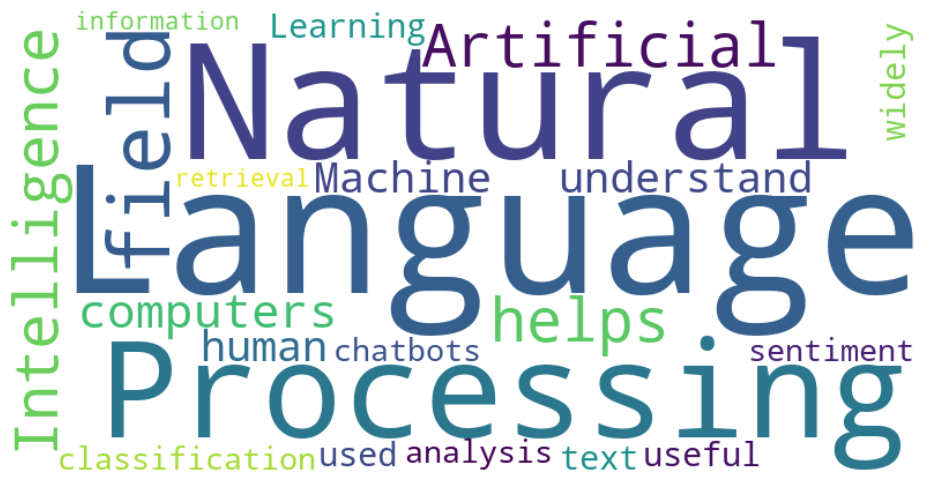

In [5]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 8. Understanding the Result

The Word Cloud automatically determines the relative importance of words based on their frequency in the input text.

For example, if the text contains:

```text
NLP       → 10 occurrences
language  → 8 occurrences
machine   → 5 occurrences
chatbot   → 3 occurrences
```

`NLP` will normally appear larger than `chatbot`.

**Interpretation:** Larger words indicate higher frequency in the supplied text.

## 9. Why Do We Need Stopwords?

Natural language contains many very common words such as:

`the`, `is`, `are`, `was`, `and`, `of`, `to`, `in`

These words are called **stopwords** in many NLP preprocessing tasks. They can occur very frequently but may not provide much useful information for a Word Cloud.

Removing stopwords helps highlight more meaningful content words.

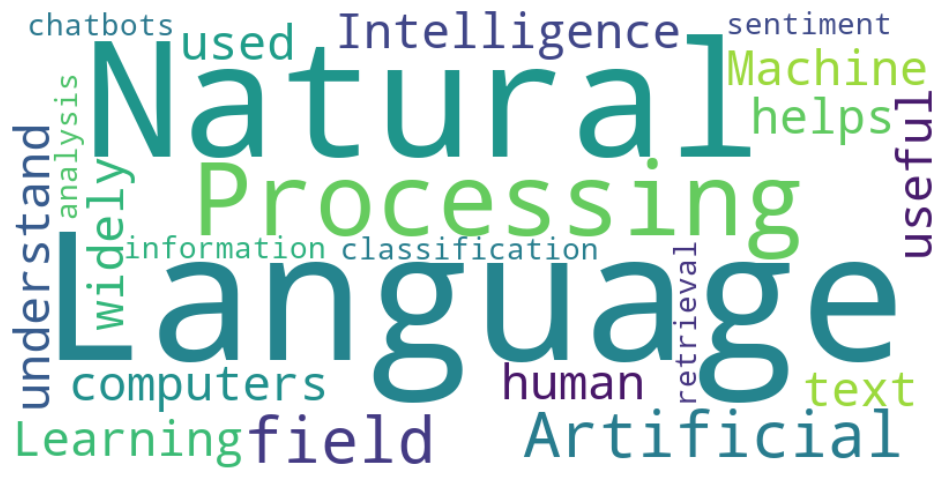

In [6]:
stopwords = set(STOPWORDS)

wordcloud_stopwords = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_stopwords, interpolation="bilinear")
plt.axis("off")
plt.show()

## 10. Basic Word Cloud vs Word Cloud with Stopwords

The first Word Cloud includes all words that meet the library's processing rules. The second explicitly removes common English stopwords.

After removing stopwords, meaningful words such as **Natural**, **Language**, **Processing**, **Machine**, **Learning**, **sentiment**, and **chatbots** become easier to identify.

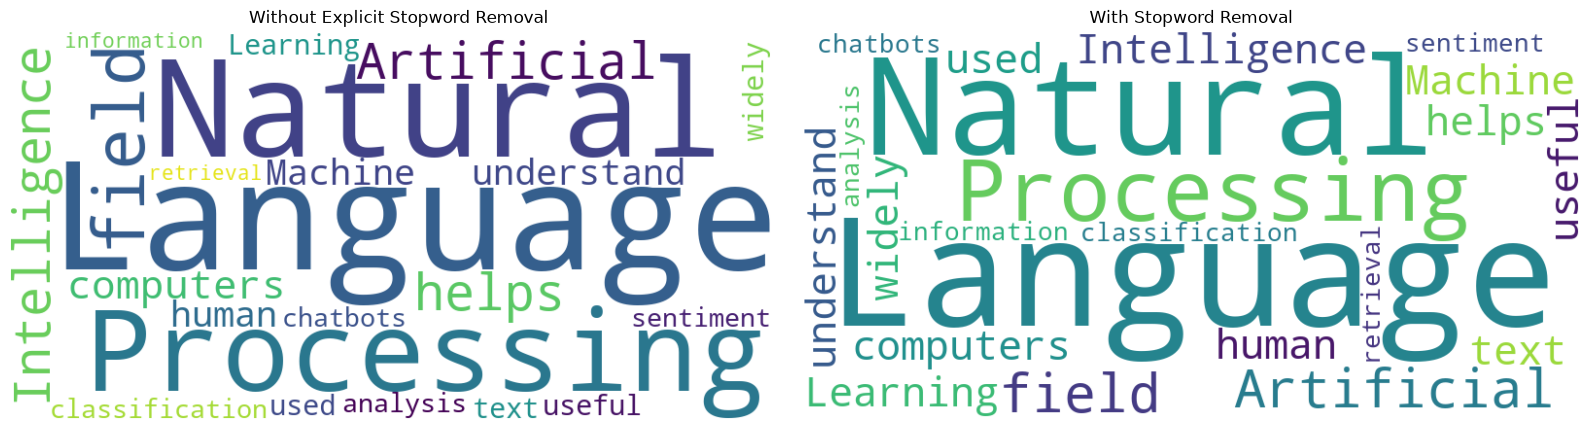

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wordcloud, interpolation="bilinear")
axes[0].set_title("Without Explicit Stopword Removal")
axes[0].axis("off")

axes[1].imshow(wordcloud_stopwords, interpolation="bilinear")
axes[1].set_title("With Stopword Removal")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 11. Generate a Word Cloud from a Text File

A Word Cloud does not have to use text typed directly into Python. We can read text from a `.txt` file.

Place a file named **`sample.txt`** in the same folder as this notebook before running the next cell.

The `encoding='utf-8'` option supports a wide range of text characters.

In [8]:
# Change the filename if your text file has a different name.
filename = "sample.txt"

with open(filename, "r", encoding="utf-8") as file:
    file_text = file.read()

file_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set(STOPWORDS)
).generate(file_text)

plt.figure(figsize=(15, 7))
plt.imshow(file_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'sample.txt'

### If `sample.txt` is not available

The previous cell will produce a `FileNotFoundError`. This is expected if the file has not been placed beside the notebook.

For demonstration purposes, the following cell creates a small `sample.txt` automatically and then generates its Word Cloud.

In [ ]:
demo_text = """
Natural Language Processing enables computers to process human language.
NLP is used in sentiment analysis, text classification, machine translation,
question answering, information retrieval, chatbots and text summarization.
Machine learning and deep learning are important technologies in modern NLP.
"""

with open("sample_demo.txt", "w", encoding="utf-8") as file:
    file.write(demo_text)

with open("sample_demo.txt", "r", encoding="utf-8") as file:
    demo_text_read = file.read()

demo_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set(STOPWORDS)
).generate(demo_text_read)

plt.figure(figsize=(15, 7))
plt.imshow(demo_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 12. Complete Word Cloud Program – Recommended Classroom Version

The following is a compact version that students can reuse for their own text.

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

text = """
Natural Language Processing is an important area of Artificial Intelligence.
NLP helps computers understand and process human language.
NLP is used for sentiment analysis, text classification, chatbots,
machine translation, information retrieval and text summarization.
"""

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set(STOPWORDS),
    min_font_size=10
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 13. Important Parameters of `WordCloud()`

| Parameter | Purpose |
|---|---|
| `width` | Width of the generated image |
| `height` | Height of the generated image |
| `background_color` | Background colour |
| `stopwords` | Words to exclude |
| `min_font_size` | Minimum font size |
| `max_words` | Maximum number of words to display |
| `collocations` | Controls common word-pair handling |
| `random_state` | Helps produce reproducible layouts |

Example:

```python
WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set(STOPWORDS),
    max_words=100,
    random_state=42
)
```

## 14. Save the Word Cloud as an Image

The generated Word Cloud can be saved as a PNG image using `to_file()`.

In [ ]:
wordcloud.to_file("wordcloud_output.png")
print("Word Cloud saved as wordcloud_output.png")

## 15. Key Learning Points

1. A Word Cloud is a visual representation of word frequency.
2. Frequently occurring words are generally displayed larger.
3. `WordCloud` is the main Python library used for generation.
4. `matplotlib` is used to display the generated image.
5. Stopwords can be removed to focus attention on meaningful words.
6. Text can be supplied directly or read from a text file.
7. A Word Cloud is useful for quick exploratory analysis of textual data.
8. A Word Cloud does not replace deeper NLP analysis such as sentiment analysis, topic modelling, or text classification.

## 16. Student Practice Exercises



### Exercise 1
Create a Word Cloud using your own paragraph about **Artificial Intelligence**.

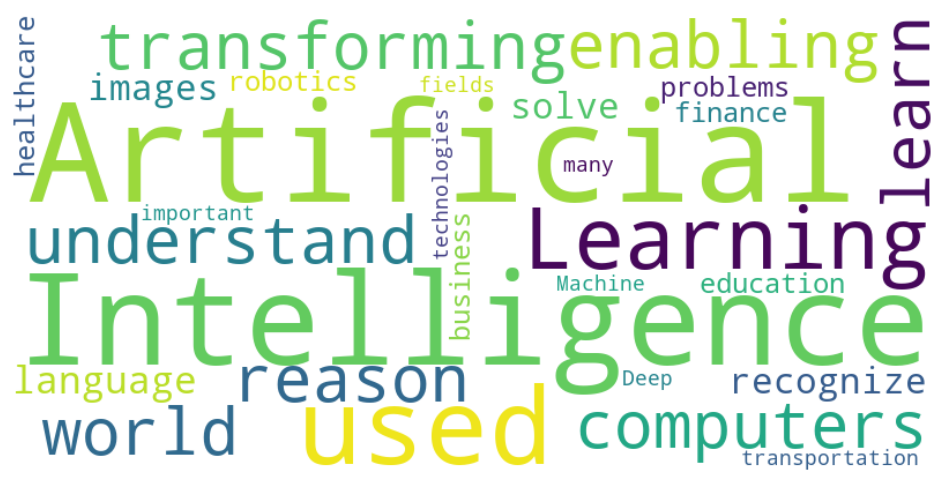

In [9]:
ai_text = """
Artificial Intelligence is transforming the world by enabling computers
to learn, reason, understand language, recognize images, and solve problems.
Artificial Intelligence is used in healthcare, education, finance, robotics,
business, transportation, and many other fields. Machine Learning and Deep
Learning are important technologies used in Artificial Intelligence.
"""

ai_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ai_text)

plt.figure(figsize=(12, 6))
plt.imshow(ai_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Exercise 2
Create a Word Cloud from 10 customer reviews and remove English stopwords.

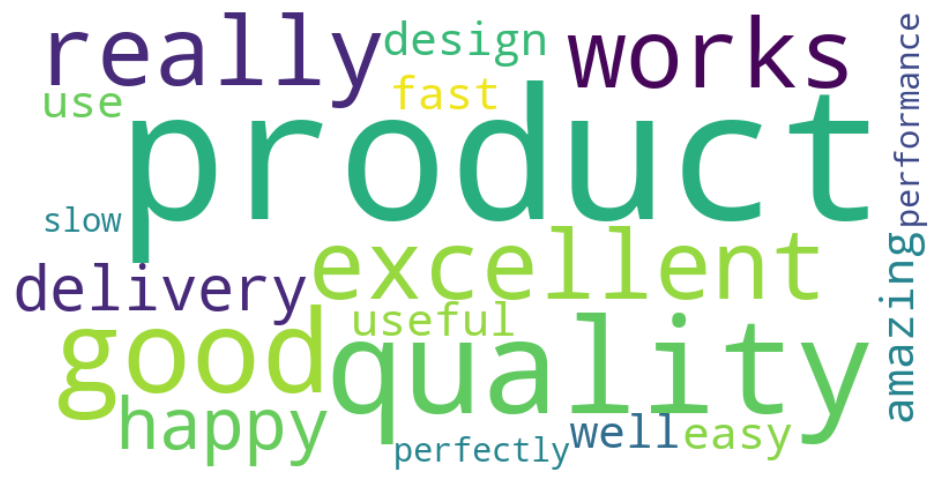

In [10]:
reviews = """
The product is very good and the quality is excellent.
I really like this product and it works very well.
The quality of the product is amazing.
This product is good and easy to use.
I am very happy with this product.
The product quality is excellent and delivery was fast.
I really like the design and quality.
This is a very useful product and works perfectly.
The product is good but the delivery was slow.
I am happy with the product and its performance.
"""

stopwords = set(STOPWORDS)

review_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(reviews)

plt.figure(figsize=(12, 6))
plt.imshow(review_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Exercise 3
Read a `.txt` news article and identify the five most visually prominent words.

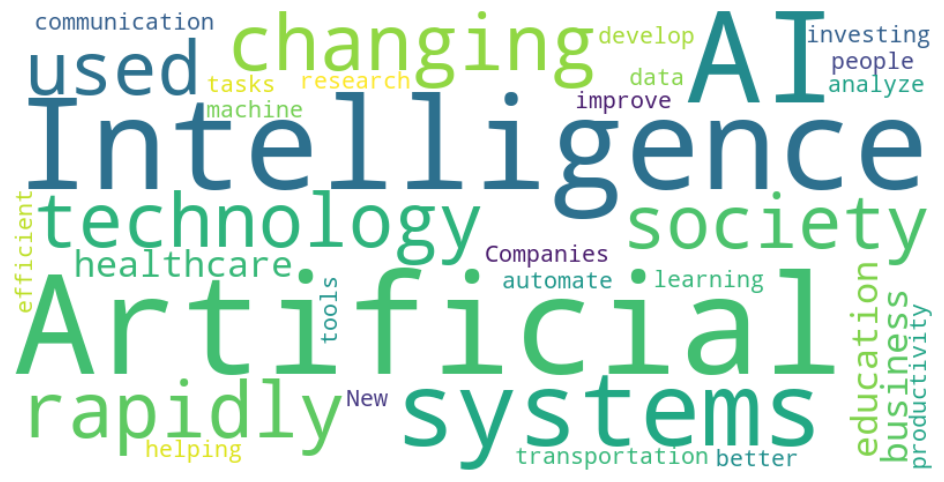

In [17]:
with open("news_article.txt", "r", encoding="utf-8") as file:
    news_text = file.read()

news_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
).generate(news_text)

plt.figure(figsize=(12, 6))
plt.imshow(news_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### To identify the five most frequent/prominent words:

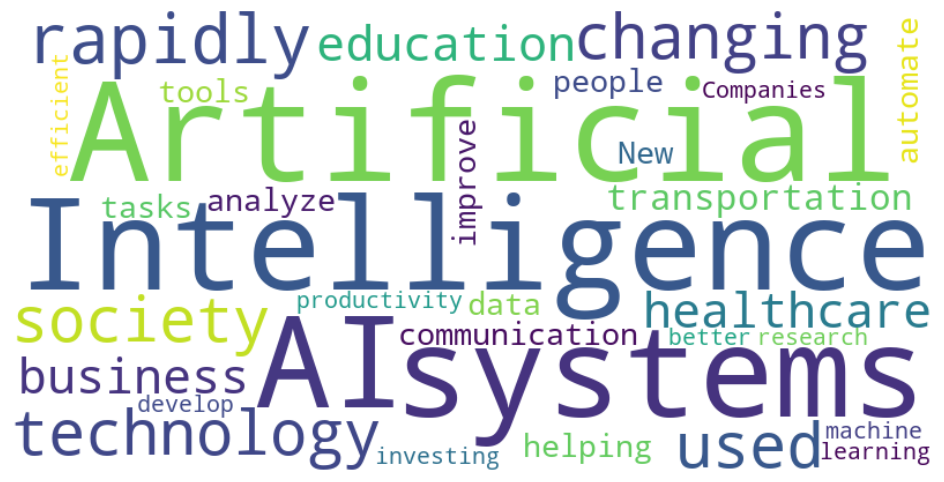

Five most prominent words:
artificial : 2
intelligence : 2
ai : 2
systems : 2
rapidly : 1


In [18]:
from collections import Counter
import re

news_text = """
Artificial Intelligence is rapidly changing technology and society.
AI systems are being used in healthcare, education, business, transportation,
and communication. New artificial intelligence tools are helping people
analyze data, automate tasks, and improve productivity.
Companies are investing in machine learning and AI research to develop
better and more efficient systems.
"""

# Create Word Cloud
news_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
).generate(news_text)

plt.figure(figsize=(12, 6))
plt.imshow(news_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Find five most frequent words
words = re.findall(r'\b[a-zA-Z]+\b', news_text.lower())

filtered_words = [
    word for word in words
    if word not in STOPWORDS
]

word_counts = Counter(filtered_words)

top_5_words = word_counts.most_common(5)

print("Five most prominent words:")
for word, count in top_5_words:
    print(word, ":", count)

### Exercise 4
Experiment with `max_words`, `min_font_size`, `width`, and `height`.


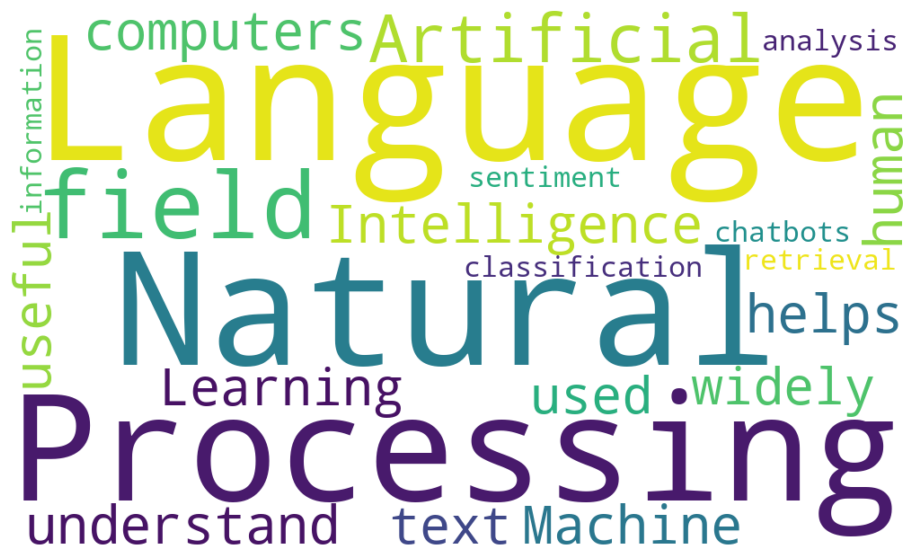

In [19]:
experiment_wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=50,
    min_font_size=10
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(experiment_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Exercise 5
Compare the Word Cloud before and after stopword removal and explain the difference.


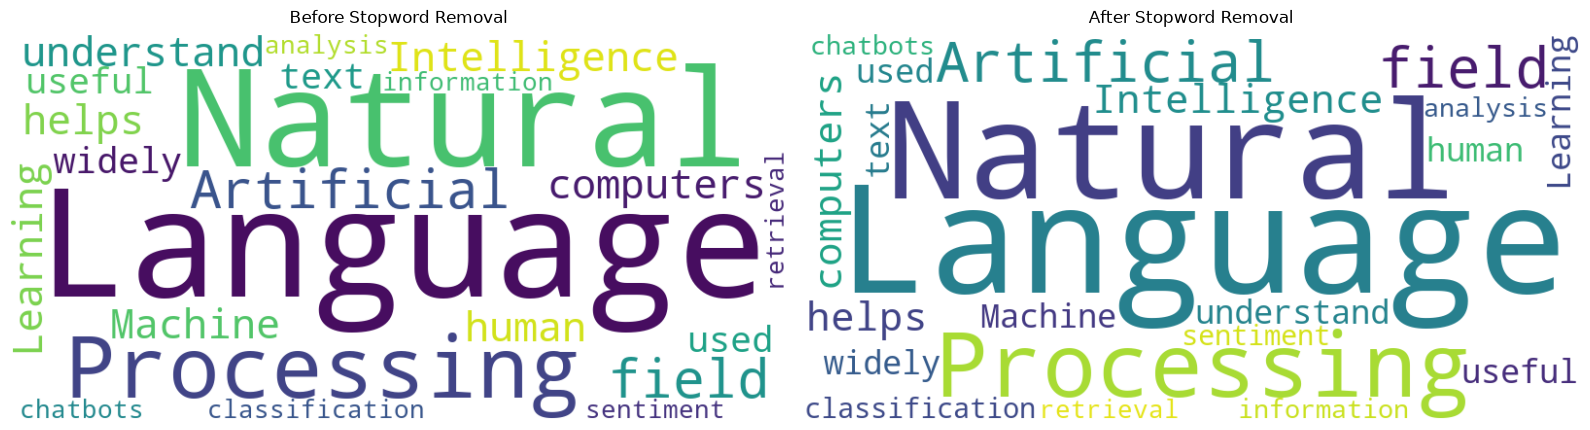

In [20]:
# Word Cloud without stopword removal
wordcloud_before = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

# Word Cloud with stopword removal
wordcloud_after = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
).generate(text)

# Display both
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wordcloud_before, interpolation="bilinear")
axes[0].set_title("Before Stopword Removal")
axes[0].axis("off")

axes[1].imshow(wordcloud_after, interpolation="bilinear")
axes[1].set_title("After Stopword Removal")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Conclusion

Word Cloud generation is a simple and useful introductory NLP visualization technique. It converts textual information into a visual form based primarily on word frequency. It is especially useful during exploratory text analysis because it allows students and analysts to quickly identify frequently occurring terms in a document or collection of documents.

**NLP concept demonstrated:** Text → Word Frequency → Stopword Removal → Visualization